# Итоговая контрольная работа по треку "Искуственный интеллект и большие данные: Временные ряды"
Выполнила:
Черанёва Наталья
### Тема:
Анализ  и  прогнозирование  многомерного  временного  ряда  с 
использованием классических методов машинного обучения и нейронных 
сетей 
### Цель:
Необходимо  самостоятельно реализовать полный pipeline анализа 
многомерного временного ряда: от предобработки данных до сравнения 
моделей и интерпретации результатов.

## Описание датасета

Датасет mpi_roof.csv содержит метеорологические параметры и данные о солнечной радиации, собранные на крыше Института биогеохимии Макса Планка.

Признаки (описание основных)

| № | Признак | Описание | Ед. измерения |
|---|---------|----------|---------------|
| 1 | p | Атмосферное давление | mbar |
| 2 | T | Температура воздуха | degC |
| 3 | Tpot | Потенциальная температура | K |
| 4 | Tdew | Точка росы | degC |
| 5 | rh | Относительная влажность | % |
| 6 | VPmax | Давление насыщенного пара | mbar |
| 7 | VPact | Давление пара | mbar |
| 8 | VPdef | Дефицит давления пара | mbar |
| 9 | sh | Удельная влажность | g/kg |
| 10 | H2OC | Молярная доля H2O | mmol/mol |
| 11 | rho | Плотность воздуха | g/m**3 |
| 12 | wv | Скорость ветра (средняя) | m/s |
| 13 | max.wv | Максимальная скорость ветра | m/s |
| 14 | wd | Направление ветра | deg |
| 15 | rain | Количество осадков | mm |
| 16 | raining | Флаг дождя | s |
| 17 | SWDR | Коротковолновая радиация | W/m² |
| 18 | PAR | Фотосинтетически активная радиация | µmol/m²/s |
| 19 | max.PAR | Максимальная PAR | µmol/m²/s |
| 20 | Tlog | Логарифмическая температура | degC |

In [3]:
# Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

In [4]:
# Загрузка даннных 

df = pd.read_csv('data/mpi_roof.csv', parse_dates=['Date Time'], index_col='Date Time')
n_rows, n_cols = df.shape
print(f'Размер выборки: {n_rows} строк на {n_cols} столбцов')
print(f'Типы данных:')
df.dtypes

Размер выборки: 1051920 строк на 20 столбцов
Типы данных:


p (mbar)                float64
T (degC)                float64
Tpot (K)                float64
Tdew (degC)             float64
rh (%)                  float64
VPmax (mbar)            float64
VPact (mbar)            float64
VPdef (mbar)            float64
sh (g/kg)               float64
H2OC (mmol/mol)         float64
rho (g/m**3)            float64
wv (m/s)                float64
max. wv (m/s)           float64
wd (deg)                float64
rain (mm)               float64
raining (s)             float64
SWDR (W/m²)             float64
PAR (µmol/m²/s)         float64
max. PAR (µmol/m²/s)    float64
Tlog (degC)             float64
dtype: object

In [107]:
# Выбор признаков для проверки стационарности

alpha = 0.05
features = df.columns.tolist() 

print('Проверка стационарности:')

def stationarity(series, feature_name):
    series_clean = series.dropna()

    dftest = adfuller(series_clean, autolag='AIC', maxlag=20)
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    
    if dfoutput["p-value"] < alpha:
        print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
    else:
        print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")
    
for feature in features:
    if feature in df.columns:
        stationarity(df[feature], feature)


Проверка стационарности:
Test Statistic                -3.408608e+01
p-value                        0.000000e+00
#Lags Used                     2.000000e+01
Number of Observations Used    1.051899e+06
Critical Value (1%)           -3.430356e+00
Critical Value (5%)           -2.861543e+00
Critical Value (10%)          -2.566771e+00
dtype: float64
Значение p меньше 5.0%. Ряд стационарный.
Test Statistic                -5.910412e+01
p-value                        0.000000e+00
#Lags Used                     2.000000e+01
Number of Observations Used    1.051899e+06
Critical Value (1%)           -3.430356e+00
Critical Value (5%)           -2.861543e+00
Critical Value (10%)          -2.566771e+00
dtype: float64
Значение p меньше 5.0%. Ряд стационарный.
Test Statistic                -5.922601e+01
p-value                        0.000000e+00
#Lags Used                     2.000000e+01
Number of Observations Used    1.051899e+06
Critical Value (1%)           -3.430356e+00
Critical Value (5%)      

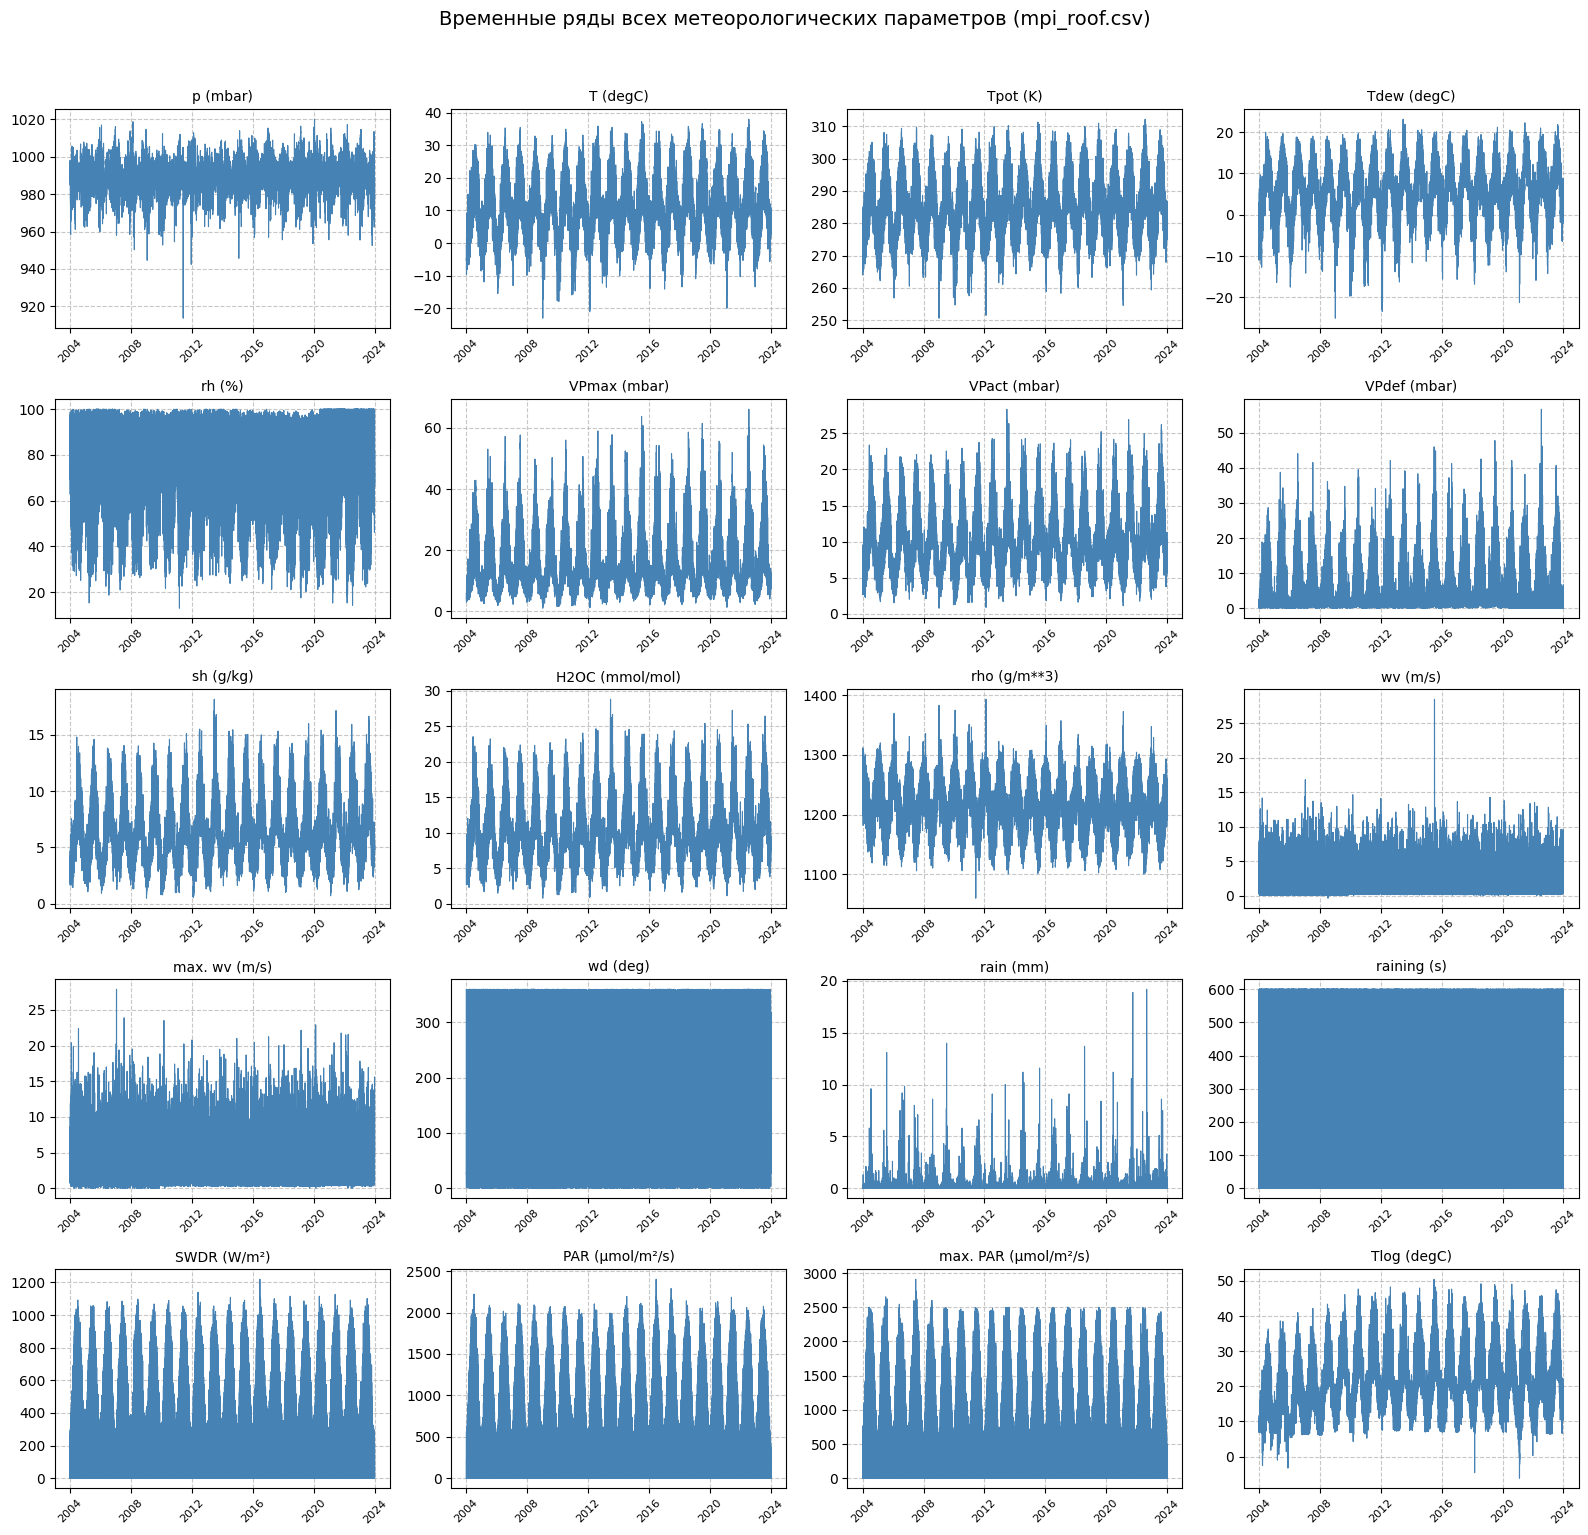

In [108]:
features_to_plot = features
n_features = len(features_to_plot)

n_cols_plot = 4
n_rows_plot = (n_features + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 3 * n_rows_plot))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    ax.plot(df.index, df[feature], linewidth=0.8, color='steelblue')
    ax.set_title(feature, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# Скрываем лишние пустые подграфики
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Временные ряды всех метеорологических параметров (mpi_roof.csv)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Анализ ряда

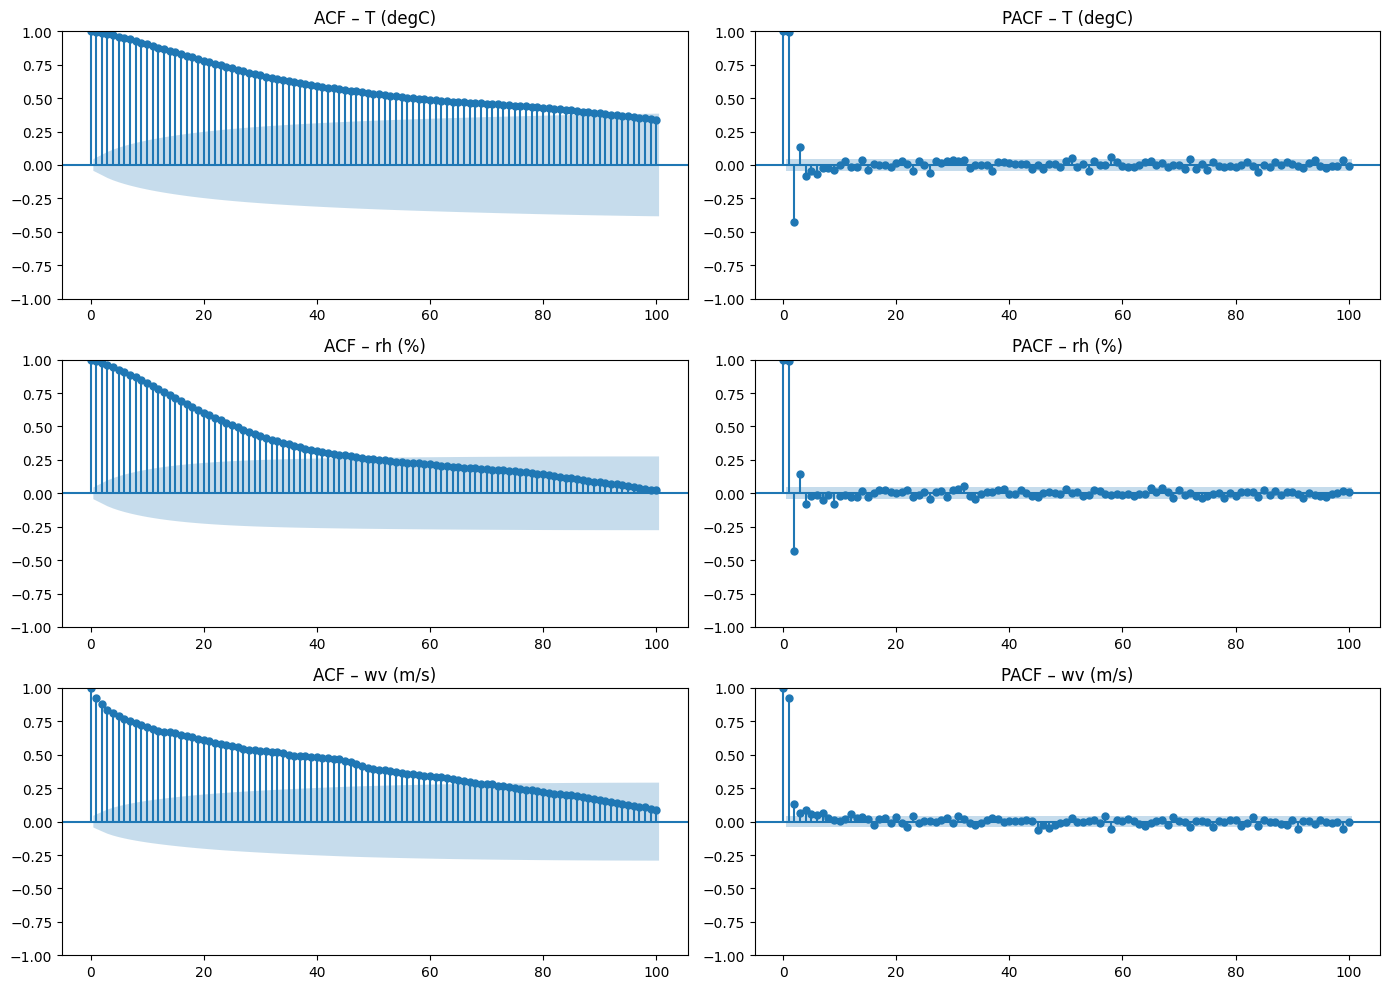

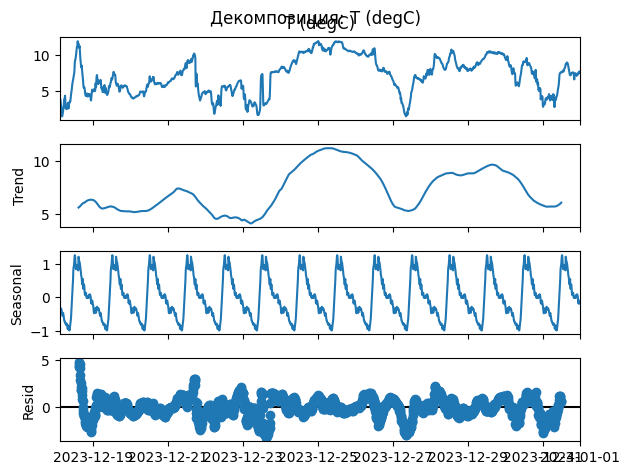

In [109]:
# Берём последние 20 000 точек 
df_sample = df.iloc[-2000:]   

series = ['T (degC)', 'rh (%)', 'wv (m/s)']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))

for i, col in enumerate(series):
    data = df_sample[col].dropna()
    plot_acf(data, lags=100, ax=axes[i, 0])
    axes[i, 0].set_title(f'ACF – {col}')
    plot_pacf(data, lags=100, ax=axes[i, 1], method='ywm')
    axes[i, 1].set_title(f'PACF – {col}')

plt.tight_layout()
plt.show()

col = 'T (degC)'
decomp = seasonal_decompose(df_sample[col].dropna(), model='additive', period=144)  # 144 = 24ч * 6
decomp.plot()
plt.suptitle(f'Декомпозиция: {col}')
plt.show()

In [110]:
# Выбросы
features_out = ['T (degC)', 'wv (m/s)', 'max. wv (m/s)', 'rain (mm)']
mask = pd.Series(True, index=df.index)

# Копируем данные для обработки
df_clean = df[mask].copy()

removed_total = 0
while True:
    mask = pd.Series(True, index=df_clean.index)
    for col in features_out:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask &= (df_clean[col] >= lower) & (df_clean[col] <= upper)
    
    new_len = mask.sum()
    if new_len == len(df_clean):
        break  
    removed_total += len(df_clean) - new_len
    df_clean = df_clean[mask].copy()

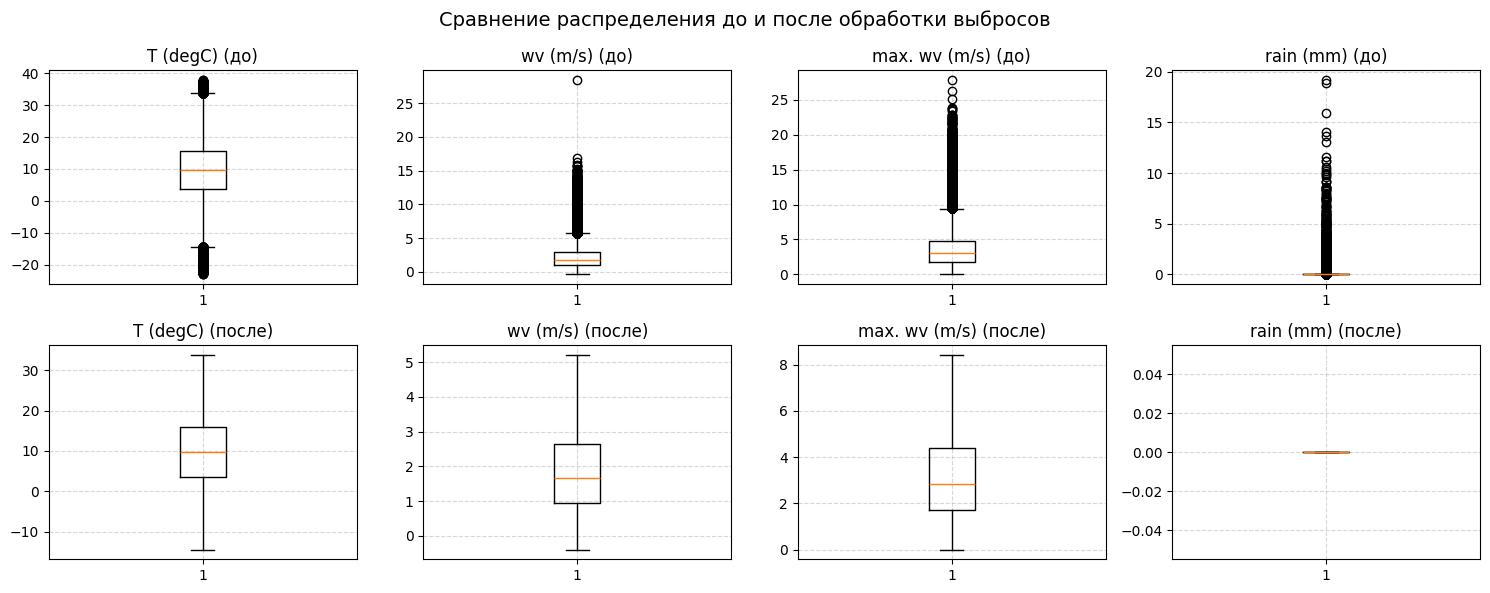

In [111]:
# Признаки, на которых интересно посмотреть выбросы
fig, axes = plt.subplots(2, len(features_out), figsize=(15, 6))
fig.suptitle('Сравнение распределения до и после обработки выбросов', fontsize=14)

for i, col in enumerate(features_out):
    # До обработки (оригинальные данные)
    axes[0, i].boxplot(df[col].dropna(), vert=True)
    axes[0, i].set_title(f'{col} (до)')
    axes[0, i].grid(True, linestyle='--', alpha=0.5)
    
    # После обработки (df_clean)
    axes[1, i].boxplot(df_clean[col].dropna(), vert=True)
    axes[1, i].set_title(f'{col} (после)')
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [112]:
# интерполяция

print("Пропуски до интерполяции:\n", df_clean.isnull().sum())
df_clean.interpolate(method='linear', inplace=True)
print("Пропуски после интерполяции:\n", df_clean.isnull().sum())

Пропуски до интерполяции:
 p (mbar)                0
T (degC)                0
Tpot (K)                0
Tdew (degC)             0
rh (%)                  0
VPmax (mbar)            0
VPact (mbar)            0
VPdef (mbar)            0
sh (g/kg)               0
H2OC (mmol/mol)         0
rho (g/m**3)            0
wv (m/s)                0
max. wv (m/s)           0
wd (deg)                0
rain (mm)               0
raining (s)             0
SWDR (W/m²)             0
PAR (µmol/m²/s)         0
max. PAR (µmol/m²/s)    0
Tlog (degC)             0
dtype: int64
Пропуски после интерполяции:
 p (mbar)                0
T (degC)                0
Tpot (K)                0
Tdew (degC)             0
rh (%)                  0
VPmax (mbar)            0
VPact (mbar)            0
VPdef (mbar)            0
sh (g/kg)               0
H2OC (mmol/mol)         0
rho (g/m**3)            0
wv (m/s)                0
max. wv (m/s)           0
wd (deg)                0
rain (mm)               0
raining (s)         

In [ ]:
# encoding/ преобразование циклических признаков. То есть направление ветра разделяем на две компоненты:
# синус и косинус от угла, чтобы сохранить информацию о цикличности

df_clean['wd_sin'] = np.sin(np.radians(df_clean['wd (deg)']))
df_clean['wd_cos'] = np.cos(np.radians(df_clean['wd (deg)']))

# Исходный столбец wd можно удалить
df_clean.drop('wd (deg)', axis=1, inplace=True)

In [114]:
# scalling
feature_names = df_clean.columns.tolist()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(scaled_data, columns=feature_names, index=df_clean.index)

data = df_scaled.copy()
for lag in [1, 3, 6, 12, 24, 48]:
    data[f'T_lag_{lag}'] = data['T (degC)'].shift(lag)
    data[f'rh_lag_{lag}'] = data['rh (%)'].shift(lag)

for win in [6, 12, 24]:
    data[f'T_roll_mean_{win}'] = data['T (degC)'].rolling(win).mean()
    data[f'T_roll_std_{win}'] = data['T (degC)'].rolling(win).std()

for win in [12, 24]:
    data[f'T_min_{win}'] = data['T (degC)'].rolling(win).min()
    data[f'T_max_{win}'] = data['T (degC)'].rolling(win).max()

data.dropna(inplace=True)

data = data.iloc[:100000]
print(f"Размер data после подвыборки: {data.shape}")

 #Целевая переменная (прогноз температуры на 6 часов = 36 шагов)
horizon = 36
y_all = data['T (degC)'].shift(-horizon).dropna()
X_all = data.iloc[:-horizon, :]
X_all, y_all = X_all.align(y_all, join='inner', axis=0)

train_size = int(0.7 * len(X_all))
val_size   = int(0.15 * len(X_all))

X_train = X_all.iloc[:train_size]
X_val   = X_all.iloc[train_size:train_size+val_size]
X_test  = X_all.iloc[train_size+val_size:]

y_train = y_all.iloc[:train_size]
y_val   = y_all.iloc[train_size:train_size+val_size]
y_test  = y_all.iloc[train_size+val_size:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Размер data после подвыборки: (100000, 43)
Train: (69974, 43), Val: (14994, 43), Test: (14996, 43)


In [115]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)
print("\nRandom Forest:")
print(f"MSE: {mse_rf:.6f}, MAE: {mae_rf:.6f}, R2 : {r2_rf:.6f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   31.5s



Random Forest:
MSE: 0.194444, MAE: 0.324319, R2 : 0.654475


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.6min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [116]:
time_steps = 72 # Решила сделать 12 часов

def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X.iloc[i:i+time_steps].values)
        y_seq.append(y.iloc[i+time_steps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)

# LSTM модель
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_steps, X_train.shape[1]), kernel_regularizer=l2(0.0005)), 
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20, batch_size=64, callbacks=[early_stop], verbose=1
)

y_pred_lstm = model_lstm.predict(X_test_seq).flatten()
mse_lstm = mean_squared_error(y_test_seq, y_pred_lstm)
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print("LSTM:")
print(f"MSE: {mse_lstm:.6f}, MAE: {mae_lstm:.6f}, R2: {r2_lstm:.6f}")

c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.1336 - mae: 0.2520 - val_loss: 0.1173 - val_mae: 0.2411
Epoch 2/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 52s 48ms/step - loss: 0.0835 - mae: 0.2051 - val_loss: 0.1482 - val_mae: 0.2815
Epoch 3/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 51s 47ms/step - loss: 0.0704 - mae: 0.1904 - val_loss: 0.1347 - val_mae: 0.2742
Epoch 4/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 97s 89ms/step - loss: 0.0620 - mae: 0.1784 - val_loss: 0.1296 - val_mae: 0.2722
Epoch 5/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 91s 84ms/step - loss: 0.0558 - mae: 0.1694 - val_loss: 0.1416 - val_mae: 0.2856
Epoch 6/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 92s 84ms/step - loss: 0.0514 - mae: 0.1621 - val_loss: 0.1356 - val_mae: 0.2788
Epoch 7/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 85s 77ms/step - loss: 0.0477 - mae: 0.1554 - val_loss: 0.1489 - val_mae: 0.2902
Epoch 8/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 85s 78ms/step - loss: 0.0455 - mae: 0.1512 - val_loss: 0.1422 - val_mae: 0.2862
Epoch 9/20
1093/1093 ━━━

In [117]:
model_cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(time_steps, X_train.shape[1])),
    MaxPooling1D(2),
    Conv1D(16, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1)
])
model_cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop_cnn = EarlyStopping(patience=5, restore_best_weights=True)

history_cnn = model_cnn.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20, batch_size=64, callbacks=[early_stop_cnn], verbose=1
)

y_pred_cnn = model_cnn.predict(X_test_seq).flatten()
mse_cnn = mean_squared_error(y_test_seq, y_pred_cnn)
mae_cnn = mean_absolute_error(y_test_seq, y_pred_cnn)
r2_cnn  = r2_score(y_test_seq, y_pred_cnn)
print("\nCNN:")
print(f"MSE: {mse_cnn:.6f}, MAE: {mae_cnn:.6f}, R2 : {r2_cnn:.6f}")

c:\Users\Nataly\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.1470 - mae: 0.2890 - val_loss: 0.1151 - val_mae: 0.2630
Epoch 2/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.1004 - mae: 0.2455 - val_loss: 0.1113 - val_mae: 0.2581
Epoch 3/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0892 - mae: 0.2309 - val_loss: 0.1621 - val_mae: 0.3061
Epoch 4/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0808 - mae: 0.2197 - val_loss: 0.1138 - val_mae: 0.2607
Epoch 5/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0765 - mae: 0.2128 - val_loss: 0.1225 - val_mae: 0.2673
Epoch 6/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0718 - mae: 0.2062 - val_loss: 0.1309 - val_mae: 0.2840
Epoch 7/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0687 - mae: 0.2012 - val_loss: 0.1385 - val_mae: 0.2830
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

CNN:
MSE: 0.102159, MAE: 0.242913, R2 : 0.818652


## Итог:
| Модель         | MSE    | MAE    | R²    |
|----------------|--------|--------|-------|
| LSTM           | 0.1002 | 0.2401 | 0.822 |
| CNN            | 0.1022 | 0.2429 | 0.819 |
| Random Forest  | 0.1944 | 0.3243 | 0.654 |

LSTM - самая точная. Она лучше других угадывает погоду, потому что «помнит», что было раньше (например, если днём было жарко, то вечером температура не упадёт резко).
CNN - чуть-чуть уступает LSTM (разница совсем маленькая). CNN хорошо замечает местные изменения (например, резкое похолодание за 3 часа), но долгосрочной памяти у неё нет.
Random Forest - работает хуже всего. Она не понимает, что погода меняется постепенно во времени. Для неё каждое измерение — просто набор цифр, без связи с прошлым. Поэтому она чаще ошибается.

Рекомендуемая модель для прогнозирования температуры на 6 часов вперёд - LSTM.
Она обеспечивает наивысшую точность (R2 = 0.822) за счёт способности моделировать долговременные зависимости в многомерных метеорологических временных рядах. При необходимости ускорения обучения допустимо использовать CNN – её качество лишь незначительно уступает LSTM. Random Forest не рекомендуется для этой задачи, так как он не учитывает последовательный характер данных.